[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](
https://colab.research.google.com/github/mhuertascompany/euclid-school-2026/blob/main/Y1/notebooks/3-euclidzoo_cnn.ipynb)

# Galaxy zoo image classification - basics with PyTorch
## Ecole Rodolphe Cledassou 2026

> Marc Huertas-Company & Hubert Bretonnière 

This notebook illustrates how to train a simple CNN from scratch to estimate the morphologies of galaxies observed with the Euclid Space Telescope. The training set is composed of galaxy stamps labeled by visual inspection through citizen science

## Loading and exploring the datasets

The data is on the github.

Unzip it locally and update the `PATH_TO_DATADIR` according to your system.

For collab, you ll need also the .zip version


In [1]:
import torch
import numpy as np
import os, shutil, glob

from datasets import load_dataset, disable_caching

PATH_TO_DATADIR = "zoo-data"

import os, shutil, glob
from datasets import load_dataset

# 1) Remove global caches of imagefolder
hf_home = os.path.expanduser("~/.cache/huggingface/datasets")
for p in glob.glob(os.path.join(hf_home, "imagefolder", "default-*")):
    print("Removing global cache:", p)
    shutil.rmtree(p, ignore_errors=True)

# 2) Remove your project-local cache as well
local_cache = os.path.abspath("./.hf_cache")
print("Removing local cache:", local_cache)
shutil.rmtree(local_cache, ignore_errors=True)
os.makedirs(local_cache, exist_ok=True)



Removing local cache: /Users/hubertbretonniere/work/astrophysics/ede_2026/euclid-school-2026/Y1/notebooks/.hf_cache


/opt/homebrew/Caskroom/miniconda/base/envs/euclid-school/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# # If you are in google collab, uncomment this cell and run it:
# # It will ask you to uplad a file, upload euclid-zoo-data.zip from the local data folder

# from google.colab import files
# uploaded = files.upload()
# path = '.'
# !unzip -q euclid-zoo-data.zip

# pip install seaborn

In [3]:

# 3) Rebuild clean
ds = load_dataset(
    "imagefolder",
    data_files={
        "train": ["zoo-data/train/*/*"],
        "test":  ["zoo-data/test/*/*"],
    },
    drop_labels=False,
    keep_in_memory=False,
    cache_dir=local_cache,
    download_mode="force_redownload",   # force a full rebuild
)
train_set, test_set = ds["train"], ds["test"]
print(train_set, test_set)

class_names = train_set.features["label"].names
# Attach a .classes attribute to both splits
for split in ("train", "test"):
    setattr(ds[split], "classes", class_names)


print(train_set.classes)
print(test_set.classes)

globals()["train_dataset_plot"] = train_set

Generating train split: 2760 examples [00:00, 29985.31 examples/s]
Generating test split: 691 examples [00:00, 46481.55 examples/s]

Dataset({
    features: ['image', 'label'],
    num_rows: 2760
}) Dataset({
    features: ['image', 'label'],
    num_rows: 691
})
['featured', 'problem', 'smooth']
['featured', 'problem', 'smooth']


In [4]:
from torchvision import transforms
from torch.utils.data import DataLoader
import torch
batch_size = 9

# 1) Define transforms (resize to fixed size, to tensor, normalize optional)
IMG_SIZE = 224  # or whatever your model expects
tfm = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),                           # PIL -> [C,H,W] float in [0,1]
    # transforms.Normalize(mean=[0.5,0.5,0.5], std=[0.5,0.5,0.5]),  # optional
])

# 2) Collate converts PIL -> tensor (+ labels)
def collate_fn(examples):
    # If images can be grayscale, force RGB for consistent 3 channels:
    imgs = [tfm(ex["image"].convert("RGB")) for ex in examples]
    labels = torch.tensor([ex["label"] for ex in examples], dtype=torch.long)
    return torch.stack(imgs, 0), labels



trainloader = torch.utils.data.DataLoader(train_set, batch_size=batch_size,
                                          shuffle=True, collate_fn=collate_fn)

testloader = torch.utils.data.DataLoader(test_set, batch_size=batch_size,
                                         shuffle=False, collate_fn=collate_fn)

globals()["train_loader_plot"] = trainloader

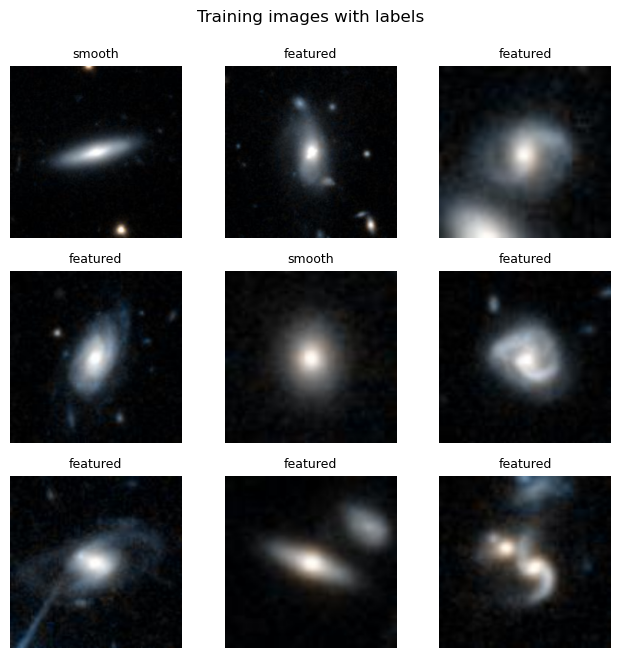

In [5]:
import torch, numpy as np, matplotlib.pyplot as plt


g = globals()

train_loader = g.get('train_loader_plot') or g.get('train_dataloader') or g.get('loader_train') or g.get('train_dl')
train_dataset = g.get('train_dataset_plot') or g.get('train_ds') or (train_loader.dataset if train_loader is not None and hasattr(train_loader, 'dataset') else None)
assert train_dataset is not None, "Could not locate a training dataset/loader. Please run the data prep cell first."

def label_name(y):
    if hasattr(train_dataset, 'classes'):
        try: return str(train_dataset.classes[int(y)])
        except: return str(y)
    if hasattr(train_dataset, 'class_to_idx'):
        rev = {v:k for k,v in train_dataset.class_to_idx.items()}
        return str(rev.get(int(y), y))
    return str(int(y))

if train_loader is not None:
    images, labels = next(iter(train_loader))
else:
    idx = torch.randperm(len(train_dataset))[:64]
    samples = [train_dataset[i] for i in idx]
    images = torch.stack([s[0] if torch.is_tensor(s[0]) else torchvision.transforms.functional.to_tensor(s[0]) for s in samples])
    labels = torch.tensor([int(s[1]) for s in samples])

B = min(images.shape[0], 64)
R = C = int(np.ceil(np.sqrt(B)))
fig, axes = plt.subplots(R, C, figsize=(2.2*C, 2.2*R))
axes = np.array(axes).reshape(R, C)

def to_display(img):
    x = img.detach().cpu().float()
    if x.ndim == 3 and x.shape[0] in (1,3):
        if x.min() < -0.1 or x.max() > 1.1:
            x = x * 0.5 + 0.5
        x = x.clamp(0,1)
        if x.shape[0] == 1: return x.squeeze(0).numpy(), 'gray'
        else: return np.transpose(x.numpy(), (1,2,0)), None
    return x.numpy(), 'gray'

for i in range(R*C):
    ax = axes[i//C, i% C]
    ax.axis('off')
    if i >= B: continue
    img, cmap = to_display(images[i])
    ax.imshow(img, cmap=cmap)
    ax.set_title(label_name(labels[i]), fontsize=9)

plt.suptitle("Training images with labels", y=0.99)
plt.tight_layout(); plt.show()

## Defining data augmentations

This will use the transformations defined in https://albumentations.ai/docs/ to augment the datasets

In [6]:
import albumentations as A
import cv2
import numpy as np

data_augmentation_pipeline = A.Compose([
    A.Rotate(
        limit=180,
        interpolation=cv2.INTER_LINEAR,
        border_mode=cv2.BORDER_CONSTANT,
        value=(0, 0, 0),         # fill color if you rotate out of frame (RGB)
        always_apply=True
    ),
    A.RandomResizedCrop(
        size=(224, 224),         # v2: use size=(H, W)
        scale=(0.7, 0.8),
        ratio=(0.9, 1.1),
        interpolation=cv2.INTER_LINEAR,
        always_apply=True
    ),
    A.VerticalFlip(p=0.5),
    A.ToFloat(max_value=255.0, always_apply=True),
])

def augment_func(samples):
    samples["pixel_values"] = [
        data_augmentation_pipeline(image=np.array(img.convert("RGB")))["image"]
        for img in samples["image"]
    ]
    return samples

train_set.set_transform(augment_func)
globals()["train_dataset"] = train_set


/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_94494/3296971643.py:6: UserWarning: Argument(s) 'value, always_apply' are not valid for transform Rotate
  A.Rotate(
/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_94494/3296971643.py:13: UserWarning: Argument(s) 'always_apply' are not valid for transform RandomResizedCrop
  A.RandomResizedCrop(
/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_94494/3296971643.py:21: UserWarning: Argument(s) 'always_apply' are not valid for transform ToFloat
  A.ToFloat(max_value=255.0, always_apply=True),


However we don't want these augmentations to be applied to the test images. We only want to standardize them.

In [7]:

standardization_pipeline = A.Compose([
    A.Resize(height=224, width=224, interpolation=1), 
    A.ToFloat(max_value=255.0, always_apply=True),
])

def standardize_func(samples):
    samples["pixel_values"] = [
        standardization_pipeline(image=np.array(image))["image"] for image in samples["image"]
    ]
    return samples

test_set.set_transform(standardize_func)

/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_94494/2571306777.py:3: UserWarning: Argument(s) 'always_apply' are not valid for transform ToFloat
  A.ToFloat(max_value=255.0, always_apply=True),


## Creating a convolutional network to extract features from the images from scratch

In [8]:
import torch.nn as nn
import torch.nn.functional as F

device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()  # for completeness (Linux/Windows)
    else torch.device("cpu")
)
print("Using:", device)

class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(3, 16, 3, 1)
        self.conv2 = nn.Conv2d(16, 32, 3, 1)
        self.conv3 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 3)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 4)
        x = self.dropout1(x)
        x = self.conv3(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return x


cnn_model = Net().to(device)

Using: mps


The loss function for this classification problem will be a cross entropy loss.

We also set up the optimizer for the training phase.

In [9]:
import torch.optim as optim

LEARNING_RATE = 1e-4

loss_fn = nn.CrossEntropyLoss()
optimizer = optim.SGD(cnn_model.parameters(), lr=LEARNING_RATE, momentum=0.9)

Before we start training, we can create a dataloader that will take the sample images from the dataset by batch of `batch_size`, apply the data augmentation and feed them to the neural network following a scheme defined in the `collate_fn` function below.

In [10]:
batch_size = 8

def collate_fn(examples):
    pixel_values = torch.stack([torch.tensor(example["pixel_values"]) for example in examples])
    labels = torch.tensor([example["label"] for example in examples])
    return  pixel_values.permute(0, 3, 1, 2), labels

trainloader = torch.utils.data.DataLoader(train_set, batch_size=batch_size,
                                          shuffle=True, collate_fn=collate_fn)

testloader = torch.utils.data.DataLoader(test_set, batch_size=batch_size,
                                         shuffle=False, collate_fn=collate_fn)


globals()["train_loader"] = trainloader
globals()["val_loader"] = testloader


## Training

This is the training script that will run for a number of epochs

In [11]:
N_EPOCHS = 30
device = (
    torch.device("mps") if torch.backends.mps.is_available()
    else torch.device("cuda") if torch.cuda.is_available()  # for completeness (Linux/Windows)
    else torch.device("cpu")
)
print("Using:", device)

for epoch in range(N_EPOCHS):  # loop over the dataset multiple times

    running_loss = 0.0
    for i, data in enumerate(trainloader, 0):
        # get the inputs; data is a list of [inputs, labels]
        inputs, labels = data
        inputs = inputs.to(device)
        labels = labels.to(device)

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = cnn_model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()

        # print statistics
        running_loss += loss.item()
        if i % 30 == 0:
            print(f'Epoch {epoch + 1:2d}, batch {i + 1:3d}] | loss: {running_loss / 30:.3f}')
            running_loss = 0.0

print('Finished Training')

Using: mps
Epoch  1, batch   1] | loss: 0.037
Epoch  1, batch  31] | loss: 1.099
Epoch  1, batch  61] | loss: 1.087
Epoch  1, batch  91] | loss: 1.075
Epoch  1, batch 121] | loss: 1.062
Epoch  1, batch 151] | loss: 1.049
Epoch  1, batch 181] | loss: 1.034
Epoch  1, batch 211] | loss: 1.020
Epoch  1, batch 241] | loss: 0.997
Epoch  1, batch 271] | loss: 0.984
Epoch  1, batch 301] | loss: 0.963
Epoch  1, batch 331] | loss: 0.949
Epoch  2, batch   1] | loss: 0.029
Epoch  2, batch  31] | loss: 0.918
Epoch  2, batch  61] | loss: 0.917
Epoch  2, batch  91] | loss: 0.881
Epoch  2, batch 121] | loss: 0.901
Epoch  2, batch 151] | loss: 0.877
Epoch  2, batch 181] | loss: 0.850
Epoch  2, batch 211] | loss: 0.867
Epoch  2, batch 241] | loss: 0.812
Epoch  2, batch 271] | loss: 0.817
Epoch  2, batch 301] | loss: 0.844
Epoch  2, batch 331] | loss: 0.816
Epoch  3, batch   1] | loss: 0.037
Epoch  3, batch  31] | loss: 0.834
Epoch  3, batch  61] | loss: 0.822
Epoch  3, batch  91] | loss: 0.826
Epoch  3,

After training we can save the model state into a file so we can load it back again later.

In [12]:
torch.save(cnn_model.state_dict(), 'convnet.pth')

## Model evaluation

Finally we can evaluate the network on the test data

In [ ]:
correct = 0
total = 0
y_true = np.array([])
y_pred = np.array([])
images_list = []
# since we're not training, we don't need to calculate the gradients for our outputs
with torch.no_grad():
    for data in testloader:
        images, labels = data
        # calculate outputs by running images through the network
        images = images.to(device)
        labels = labels.to(device)
        outputs = F.softmax(cnn_model(images), dim=1)
        images_list.append(images.cpu())
        # the class with the highest energy is what we choose as prediction
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
        y_true = np.concatenate([y_true, np.array(labels.cpu().numpy())])
        y_pred = np.concatenate([y_pred, np.array(predicted.cpu().numpy())])

print(f'Accuracy of the network on the test images: {100 * correct // total} %')

/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_94494/1052777663.py:19: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_true = np.concatenate([y_true, np.array(labels.cpu())])
/var/folders/pm/75x956bd2kl18j6xlp4m5d8c0000gp/T/ipykernel_94494/1052777663.py:20: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  y_pred = np.concatenate([y_pred, np.array(predicted.cpu())])


Accuracy of the network on the test images: 54 %


In [14]:
images_array = np.concatenate(images_list, axis=0)

Text(0.5, 0.95, 'Good predictions')

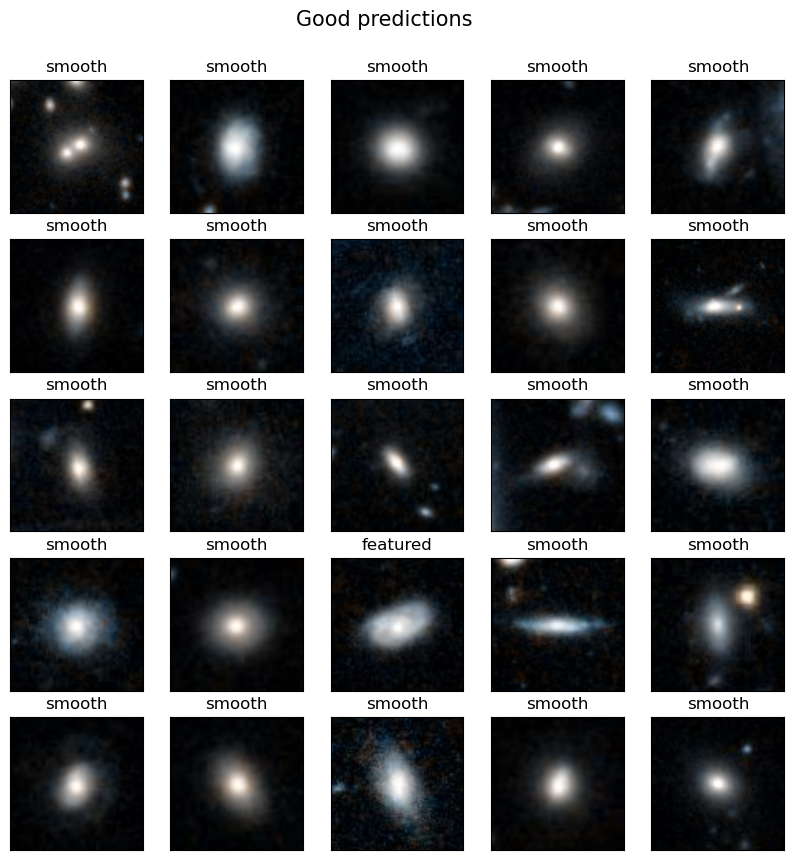

In [15]:
good_preds_ids = np.where(y_pred == y_true)[0]
rdm_25 = np.random.permutation(good_preds_ids)[:25]
fig, ax = plt.subplots(5, 5, figsize=(10, 10))
ax = ax.flatten()
for i, id in enumerate(rdm_25):
    image = np.transpose(images_array[id], (1, 2, 0))
    ax[i].imshow(image)
    ax[i].set_title(label_name(y_pred[id]))
[axe.set_xticks([]) for axe in ax]
[axe.set_yticks([]) for axe in ax]
fig.suptitle('Good predictions', y=0.95, fontsize=15)

Text(0.5, 0.95, 'Bad predictions')

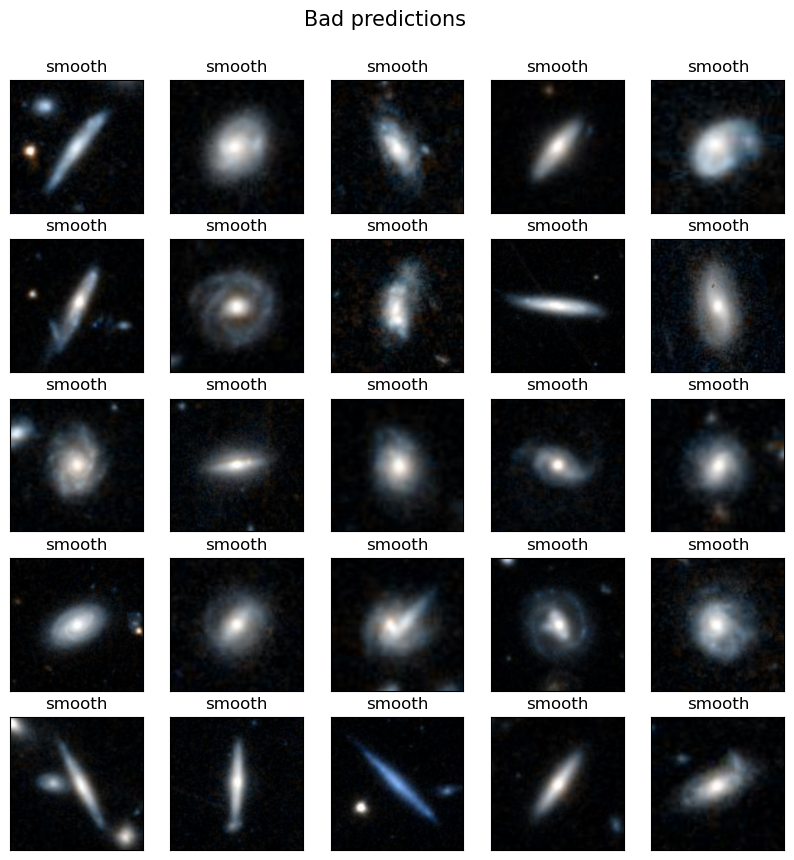

In [16]:
bad_preds_ids = np.where(y_pred != y_true)[0]
rdm_25 = np.random.permutation(bad_preds_ids)[:25]
fig, ax = plt.subplots(5, 5, figsize=(10, 10))
ax = ax.flatten()
for i, id in enumerate(rdm_25):
    image = np.transpose(images_array[id], (1, 2, 0))
    ax[i].imshow(image)
    ax[i].set_title(label_name(y_pred[id]))
[axe.set_xticks([]) for axe in ax]
[axe.set_yticks([]) for axe in ax]
fig.suptitle('Bad predictions', y=0.95, fontsize=15)

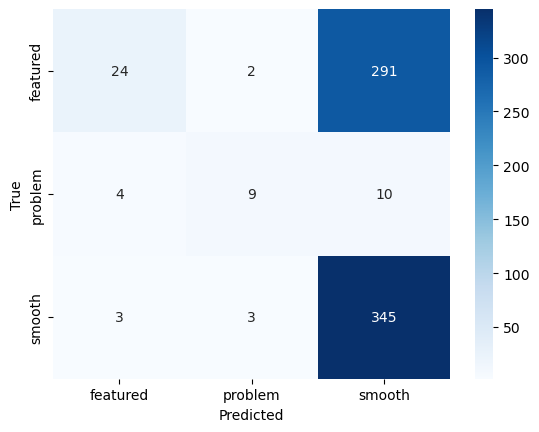

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm = confusion_matrix(y_true, y_pred, labels=[0, 1, 2])

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=[label_name(0), label_name(1), label_name(2)],
    yticklabels=[label_name(0), label_name(1), label_name(2)],
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()